# ToFデータ妥当性分析

このノートブックでは、ToF（Time-of-Flight）センサーデータの妥当性を詳細に分析します。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


In [2]:
# 実験設定
EXPERIMENT_NAME = "preprocess_v2_ws64"  # または "preprocess_v2_ws128"
DATA_DIR = Path("../output/experiments")
EXPERIMENT_DIR = DATA_DIR / EXPERIMENT_NAME

print(f"実験ディレクトリ: {EXPERIMENT_DIR}")
print(f"存在確認: {EXPERIMENT_DIR.exists()}")

実験ディレクトリ: ../output/experiments/preprocess_v2_ws64
存在確認: True


In [3]:
# ToFデータ読み込み
tof_file = EXPERIMENT_DIR / 'preprocessed' / 'train_tof_windows.pkl'
if tof_file.exists():
    with open(tof_file, 'rb') as f:
        tof_data = pickle.load(f)
    print(f"ToFデータ読み込み完了: {tof_data.shape}")
    print(f"データ型: {tof_data.dtype}")
else:
    print("ToFデータファイルが見つかりません")
    tof_data = None

ToFデータ読み込み完了: (10147, 64, 5, 8, 8)
データ型: float32


In [4]:
# ToFデータの基本統計
if tof_data is not None:
    print("📊 ToFデータ基本統計")
    print("="*50)
    
    # 形状情報
    print(f"形状: {tof_data.shape}")
    print(f"データ型: {tof_data.dtype}")
    print(f"総要素数: {tof_data.size:,}")
    
    # 基本統計
    mean_val = tof_data.mean()
    std_val = tof_data.std()
    min_val = tof_data.min()
    max_val = tof_data.max()
    
    print(f"\n基本統計:")
    print(f"平均: {mean_val:.3f}")
    print(f"標準偏差: {std_val:.3f}")
    print(f"最小値: {min_val:.3f}")
    print(f"最大値: {max_val:.3f}")
    
    # 負の値の分析
    negative_mask = tof_data < 0
    negative_count = negative_mask.sum()
    negative_ratio = negative_count / tof_data.size * 100
    
    print(f"\n⚠️ 負の値分析:")
    print(f"負の値の数: {negative_count:,}個")
    print(f"負の値の比率: {negative_ratio:.2f}%")
    
    # 負の値の詳細
    negative_values = tof_data[negative_mask]
    print(f"負の値の範囲: [{negative_values.min():.3f}, {negative_values.max():.3f}]")
    print(f"負の値の平均: {negative_values.mean():.3f}")
    print(f"負の値の標準偏差: {negative_values.std():.3f}")
    
    # 正の値の分析
    positive_mask = tof_data >= 0
    positive_count = positive_mask.sum()
    positive_ratio = positive_count / tof_data.size * 100
    
    print(f"\n✅ 正の値分析:")
    print(f"正の値の数: {positive_count:,}個")
    print(f"正の値の比率: {positive_ratio:.2f}%")
    
    if positive_count > 0:
        positive_values = tof_data[positive_mask]
        print(f"正の値の範囲: [{positive_values.min():.3f}, {positive_values.max():.3f}]")
        print(f"正の値の平均: {positive_values.mean():.3f}")
        print(f"正の値の標準偏差: {positive_values.std():.3f}")

📊 ToFデータ基本統計
形状: (10147, 64, 5, 8, 8)
データ型: float32
総要素数: 207,810,560

基本統計:
平均: 0.000
標準偏差: 1.000
最小値: -0.785
最大値: 2.454

⚠️ 負の値分析:
負の値の数: 126,851,256個
負の値の比率: 61.04%
負の値の範囲: [-0.785, -0.000]
負の値の平均: -0.707
負の値の標準偏差: 0.195

✅ 正の値分析:
正の値の数: 80,959,304個
正の値の比率: 38.96%
正の値の範囲: [0.000, 2.454]
正の値の平均: 1.107
正の値の標準偏差: 0.706


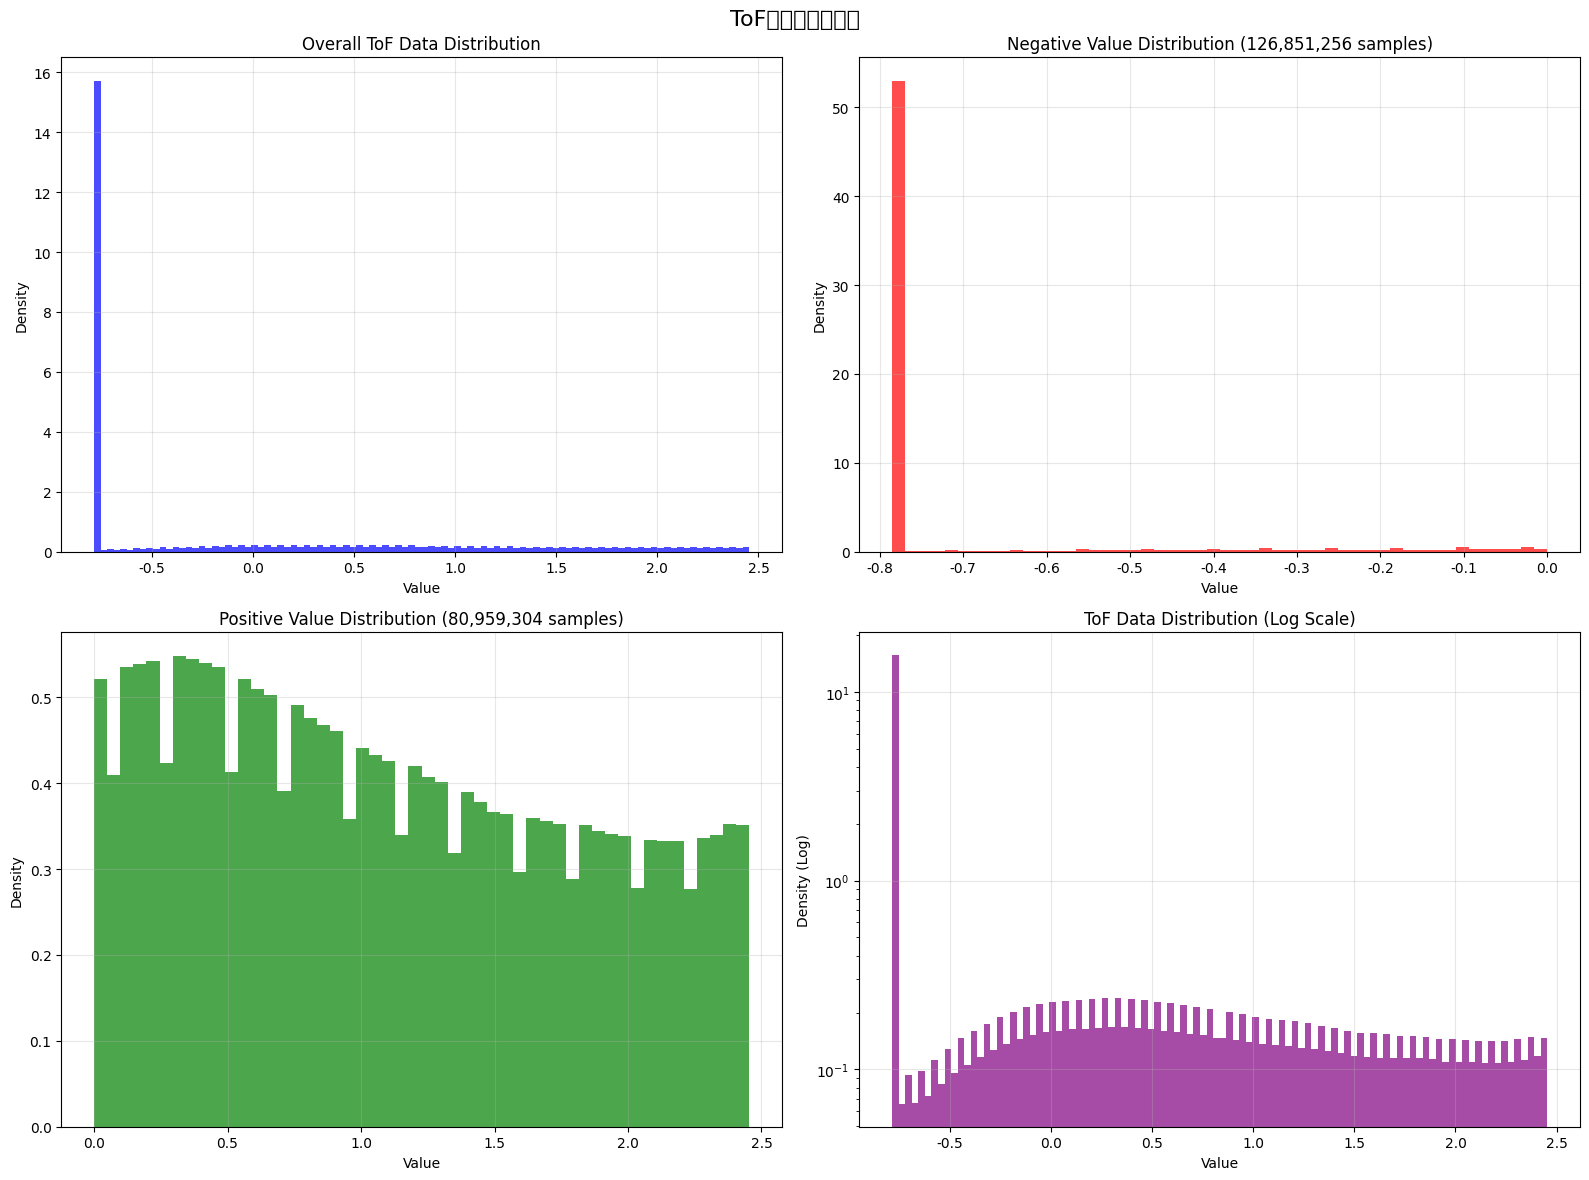

In [11]:
# ToFデータの分布分析
if tof_data is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ToFデータ分布分析', fontsize=16)
    
    # 全体の分布
    ax1 = axes[0, 0]
    ax1.hist(tof_data.flatten(), bins=100, alpha=0.7, color='blue', density=True)
    ax1.set_title('Overall ToF Data Distribution')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density')
    ax1.grid(True, alpha=0.3)
    
    # 負の値の分布
    ax2 = axes[0, 1]
    negative_values = tof_data[tof_data < 0].flatten()
    if len(negative_values) > 0:
        ax2.hist(negative_values, bins=50, alpha=0.7, color='red', density=True)
        ax2.set_title(f'Negative Value Distribution ({len(negative_values):,} samples)')
        ax2.set_xlabel('Value')
        ax2.set_ylabel('Density')
        ax2.grid(True, alpha=0.3)
    
    # 正の値の分布
    ax3 = axes[1, 0]
    positive_values = tof_data[tof_data >= 0].flatten()
    if len(positive_values) > 0:
        ax3.hist(positive_values, bins=50, alpha=0.7, color='green', density=True)
        ax3.set_title(f'Positive Value Distribution ({len(positive_values):,} samples)')
        ax3.set_xlabel('Value')
        ax3.set_ylabel('Density')
        ax3.grid(True, alpha=0.3)
    
    # 対数スケールでの分布
    ax4 = axes[1, 1]
    ax4.hist(tof_data.flatten(), bins=100, alpha=0.7, color='purple', density=True)
    ax4.set_yscale('log')
    ax4.set_title('ToF Data Distribution (Log Scale)')
    ax4.set_xlabel('Value')
    ax4.set_ylabel('Density (Log)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

📊 チャンネル別・ピクセル別分析

🔍 チャンネル別統計:
Channel 0: 平均=0.034, 標準偏差=1.016, 負の値比率=59.51%
Channel 1: 平均=-0.079, 標準偏差=0.938, 負の値比率=62.79%
Channel 2: 平均=-0.038, 標準偏差=0.985, 負の値比率=63.05%
Channel 3: 平均=0.124, 標準偏差=1.041, 負の値比率=55.81%
Channel 4: 平均=-0.041, 標準偏差=1.003, 負の値比率=64.05%

🔍 ピクセル位置別負の値比率:


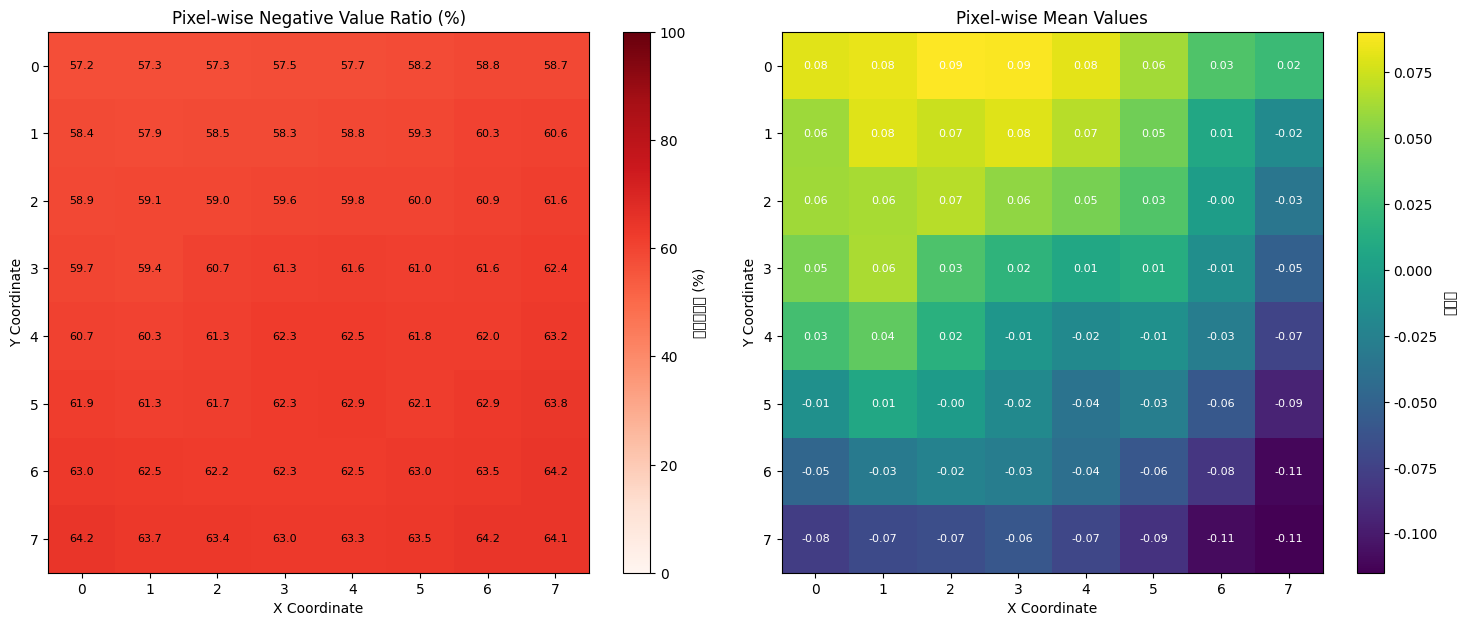

In [12]:
# チャンネル別・ピクセル別の分析
if tof_data is not None:
    print("📊 チャンネル別・ピクセル別分析")
    print("="*50)
    
    # チャンネル別統計
    print("\n🔍 チャンネル別統計:")
    for ch in range(tof_data.shape[2]):
        channel_data = tof_data[:, :, ch, :, :]
        channel_mean = channel_data.mean()
        channel_std = channel_data.std()
        channel_negative_ratio = (channel_data < 0).sum() / channel_data.size * 100
        
        print(f"Channel {ch}: 平均={channel_mean:.3f}, 標準偏差={channel_std:.3f}, 負の値比率={channel_negative_ratio:.2f}%")
    
    # ピクセル位置別の負の値比率
    print("\n🔍 ピクセル位置別負の値比率:")
    pixel_negative_ratios = np.zeros((8, 8))
    
    for i in range(8):
        for j in range(8):
            pixel_data = tof_data[:, :, :, i, j]
            negative_ratio = (pixel_data < 0).sum() / pixel_data.size * 100
            pixel_negative_ratios[i, j] = negative_ratio
    
    # ヒートマップ表示
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 負の値比率のヒートマップ
    im1 = ax1.imshow(pixel_negative_ratios, cmap='Reds', vmin=0, vmax=100)
    ax1.set_title('Pixel-wise Negative Value Ratio (%)')
    ax1.set_xlabel('X Coordinate')
    ax1.set_ylabel('Y Coordinate')
    
    # カラーバー
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('負の値比率 (%)')
    
    # ピクセル位置に値を表示
    for i in range(8):
        for j in range(8):
            ax1.text(j, i, f'{pixel_negative_ratios[i, j]:.1f}', 
                    ha='center', va='center', color='black', fontsize=8)
    
    # 平均値のヒートマップ
    pixel_means = np.zeros((8, 8))
    for i in range(8):
        for j in range(8):
            pixel_data = tof_data[:, :, :, i, j]
            pixel_means[i, j] = pixel_data.mean()
    
    im2 = ax2.imshow(pixel_means, cmap='viridis')
    ax2.set_title('Pixel-wise Mean Values')
    ax2.set_xlabel('X Coordinate')
    ax2.set_ylabel('Y Coordinate')
    
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('平均値')
    
    # ピクセル位置に値を表示
    for i in range(8):
        for j in range(8):
            ax2.text(j, i, f'{pixel_means[i, j]:.2f}', 
                    ha='center', va='center', color='white', fontsize=8)
    
    plt.tight_layout()
    plt.show()

📊 時間軸での変化分析


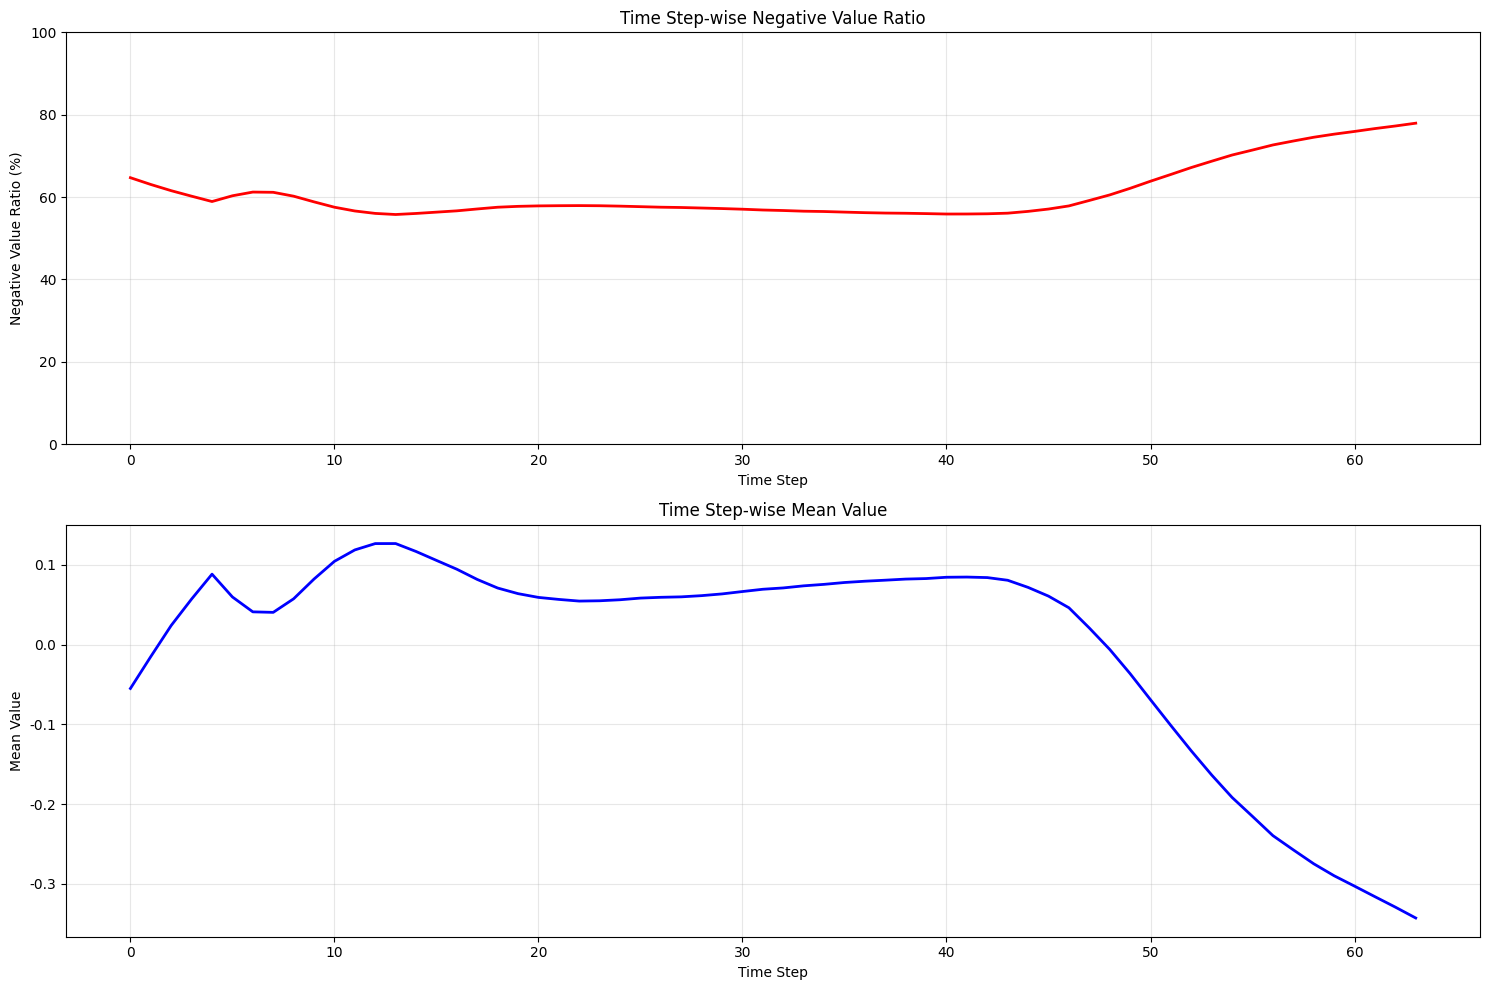


📊 時間軸統計:
負の値比率の範囲: [55.77%, 77.94%]
負の値比率の平均: 61.04%
負の値比率の標準偏差: 6.50%
平均値の範囲: [-0.343, 0.127]
平均値の標準偏差: 0.132


In [13]:
# 時間軸での変化分析
if tof_data is not None:
    print("📊 時間軸での変化分析")
    print("="*50)
    
    # 時間ステップ別の負の値比率
    time_negative_ratios = []
    time_means = []
    
    for t in range(tof_data.shape[1]):
        time_data = tof_data[:, t, :, :, :]
        negative_ratio = (time_data < 0).sum() / time_data.size * 100
        mean_val = time_data.mean()
        
        time_negative_ratios.append(negative_ratio)
        time_means.append(mean_val)
    
    # 可視化
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # 時間ステップ別負の値比率
    ax1.plot(time_negative_ratios, 'r-', linewidth=2)
    ax1.set_title('Time Step-wise Negative Value Ratio')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Negative Value Ratio (%)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 100)
    
    # 時間ステップ別平均値
    ax2.plot(time_means, 'b-', linewidth=2)
    ax2.set_title('Time Step-wise Mean Value')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Mean Value')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報
    print(f"\n📊 時間軸統計:")
    print(f"負の値比率の範囲: [{min(time_negative_ratios):.2f}%, {max(time_negative_ratios):.2f}%]")
    print(f"負の値比率の平均: {np.mean(time_negative_ratios):.2f}%")
    print(f"負の値比率の標準偏差: {np.std(time_negative_ratios):.2f}%")
    print(f"平均値の範囲: [{min(time_means):.3f}, {max(time_means):.3f}]")
    print(f"平均値の標準偏差: {np.std(time_means):.3f}")

📊 サンプル別分析


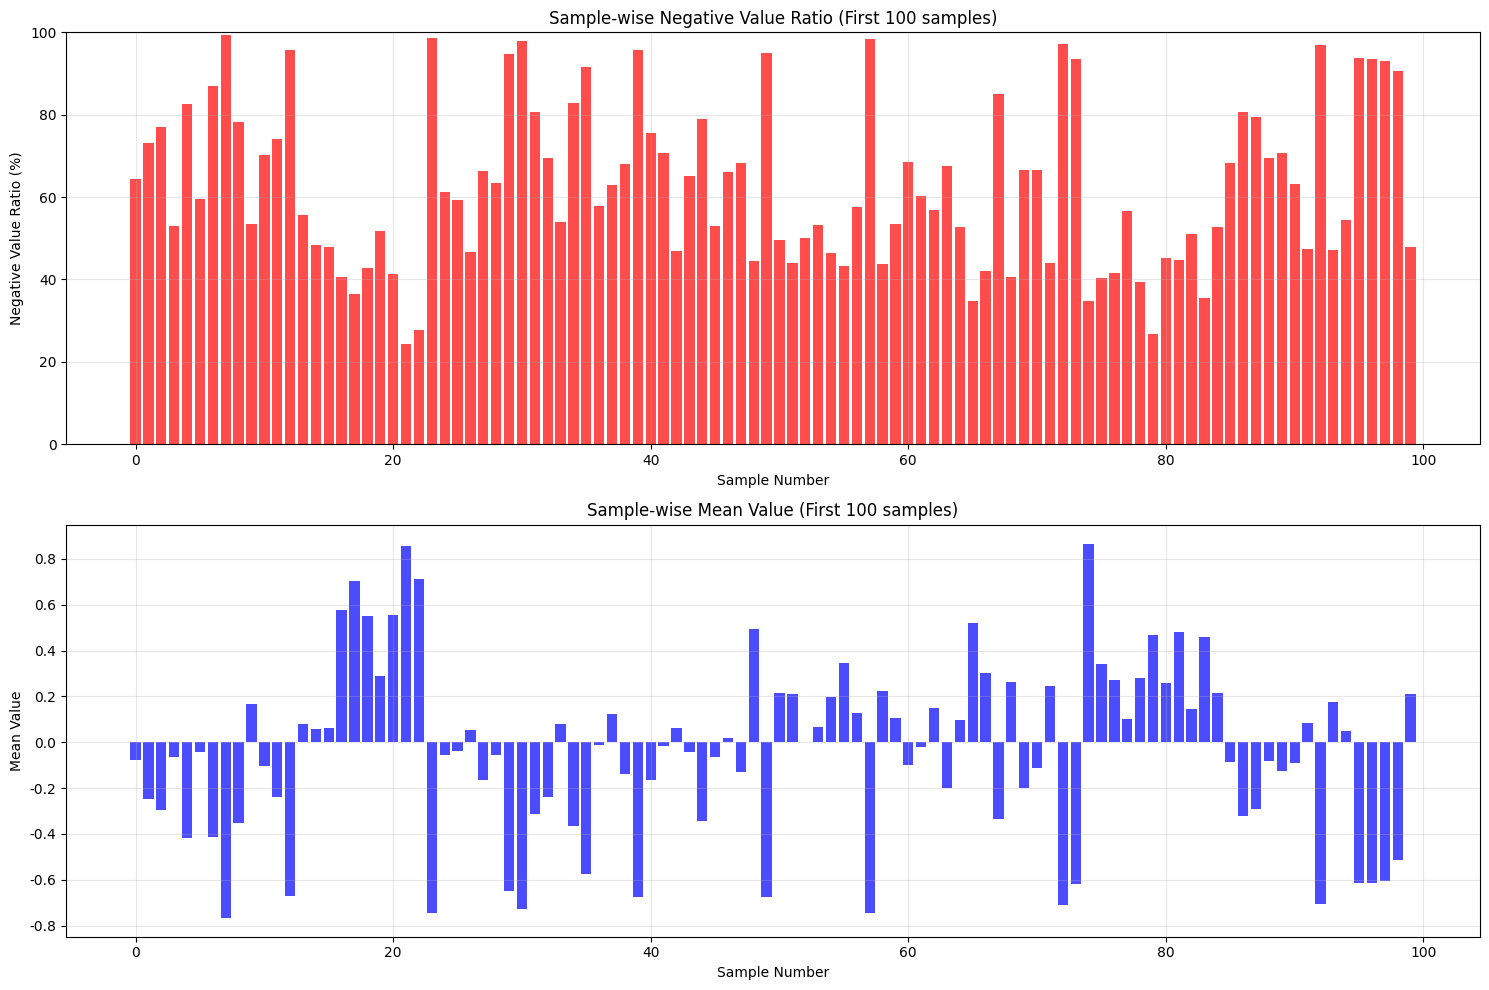


📊 サンプル別統計（最初の100サンプル）:
負の値比率の範囲: [24.40%, 99.31%]
負の値比率の平均: 62.80%
負の値比率の標準偏差: 19.53%
平均値の範囲: [-0.767, 0.867]
平均値の標準偏差: 0.380


In [14]:
# サンプル別の分析
if tof_data is not None:
    print("📊 サンプル別分析")
    print("="*50)
    
    # サンプル別の負の値比率
    sample_negative_ratios = []
    sample_means = []
    
    # 最初の100サンプルを分析
    num_samples = min(100, tof_data.shape[0])
    
    for s in range(num_samples):
        sample_data = tof_data[s, :, :, :, :]
        negative_ratio = (sample_data < 0).sum() / sample_data.size * 100
        mean_val = sample_data.mean()
        
        sample_negative_ratios.append(negative_ratio)
        sample_means.append(mean_val)
    
    # 可視化
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # サンプル別負の値比率
    ax1.bar(range(num_samples), sample_negative_ratios, alpha=0.7, color='red')
    ax1.set_title(f'Sample-wise Negative Value Ratio (First {num_samples} samples)')
    ax1.set_xlabel('Sample Number')
    ax1.set_ylabel('Negative Value Ratio (%)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 100)
    
    # サンプル別平均値
    ax2.bar(range(num_samples), sample_means, alpha=0.7, color='blue')
    ax2.set_title(f'Sample-wise Mean Value (First {num_samples} samples)')
    ax2.set_xlabel('Sample Number')
    ax2.set_ylabel('Mean Value')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報
    print(f"\n📊 サンプル別統計（最初の{num_samples}サンプル）:")
    print(f"負の値比率の範囲: [{min(sample_negative_ratios):.2f}%, {max(sample_negative_ratios):.2f}%]")
    print(f"負の値比率の平均: {np.mean(sample_negative_ratios):.2f}%")
    print(f"負の値比率の標準偏差: {np.std(sample_negative_ratios):.2f}%")
    print(f"平均値の範囲: [{min(sample_means):.3f}, {max(sample_means):.3f}]")
    print(f"平均値の標準偏差: {np.std(sample_means):.3f}")

In [9]:
# 正規化の妥当性チェック
if tof_data is not None:
    print("🔍 正規化の妥当性チェック")
    print("="*50)
    
    # 正規化後の統計
    print(f"正規化後の統計:")
    print(f"平均: {tof_data.mean():.3f} (期待値: 0.0)")
    print(f"標準偏差: {tof_data.std():.3f} (期待値: 1.0)")
    
    # 正規化の偏差
    mean_deviation = abs(tof_data.mean() - 0.0)
    std_deviation = abs(tof_data.std() - 1.0)
    
    print(f"\n正規化の偏差:")
    print(f"平均の偏差: {mean_deviation:.3f}")
    print(f"標準偏差の偏差: {std_deviation:.3f}")
    
    # 正規化の品質評価
    print(f"\n正規化の品質評価:")
    if mean_deviation < 0.1:
        print("✅ 平均の正規化: 良好")
    elif mean_deviation < 0.5:
        print("⚠️ 平均の正規化: 注意が必要")
    else:
        print("❌ 平均の正規化: 問題あり")
    
    if std_deviation < 0.1:
        print("✅ 標準偏差の正規化: 良好")
    elif std_deviation < 0.5:
        print("⚠️ 標準偏差の正規化: 注意が必要")
    else:
        print("❌ 標準偏差の正規化: 問題あり")
    
    # 負の値が正規化に与える影響
    print(f"\n負の値の影響分析:")
    
    # 正の値のみで正規化をシミュレート
    positive_data = tof_data[tof_data >= 0]
    if len(positive_data) > 0:
        positive_mean = positive_data.mean()
        positive_std = positive_data.std()
        
        print(f"正の値のみの平均: {positive_mean:.3f}")
        print(f"正の値のみの標準偏差: {positive_std:.3f}")
        
        # 負の値を含む場合の正規化の影響
        print(f"\n負の値が正規化に与える影響:")
        print(f"全体平均と正の値平均の差: {abs(tof_data.mean() - positive_mean):.3f}")
        print(f"全体標準偏差と正の値標準偏差の差: {abs(tof_data.std() - positive_std):.3f}")

🔍 正規化の妥当性チェック
正規化後の統計:
平均: 0.000 (期待値: 0.0)
標準偏差: 1.000 (期待値: 1.0)

正規化の偏差:
平均の偏差: 0.000
標準偏差の偏差: 0.000

正規化の品質評価:
✅ 平均の正規化: 良好
✅ 標準偏差の正規化: 良好

負の値の影響分析:
正の値のみの平均: 1.107
正の値のみの標準偏差: 0.706

負の値が正規化に与える影響:
全体平均と正の値平均の差: 1.107
全体標準偏差と正の値標準偏差の差: 0.294


In [10]:
# ToFデータの妥当性評価
if tof_data is not None:
    print("📋 ToFデータ妥当性評価")
    print("="*60)
    
    # 評価基準
    negative_ratio = (tof_data < 0).sum() / tof_data.size * 100
    mean_deviation = abs(tof_data.mean() - 0.0)
    std_deviation = abs(tof_data.std() - 1.0)
    
    print(f"\n🔍 評価項目:")
    
    # 1. 負の値の比率
    print(f"1. 負の値の比率: {negative_ratio:.2f}%")
    if negative_ratio < 10:
        print("   ✅ 良好: 負の値が少ない")
    elif negative_ratio < 30:
        print("   ⚠️ 注意: 負の値がやや多い")
    else:
        print("   ❌ 問題: 負の値が非常に多い")
    
    # 2. 正規化の品質
    print(f"2. 正規化の品質:")
    print(f"   平均の偏差: {mean_deviation:.3f}")
    print(f"   標準偏差の偏差: {std_deviation:.3f}")
    
    if mean_deviation < 0.1 and std_deviation < 0.1:
        print("   ✅ 良好: 正規化が適切")
    elif mean_deviation < 0.5 and std_deviation < 0.5:
        print("   ⚠️ 注意: 正規化に若干の問題")
    else:
        print("   ❌ 問題: 正規化に大きな問題")
    
    # 3. データの範囲
    data_range = tof_data.max() - tof_data.min()
    print(f"3. データの範囲: {data_range:.3f}")
    if data_range > 2.0:
        print("   ✅ 良好: 十分な範囲")
    elif data_range > 1.0:
        print("   ⚠️ 注意: 範囲がやや狭い")
    else:
        print("   ❌ 問題: 範囲が非常に狭い")
    
    # 4. 全体的な評価
    print(f"\n🎯 全体的な評価:")
    
    score = 0
    if negative_ratio < 30:
        score += 1
    if mean_deviation < 0.5:
        score += 1
    if std_deviation < 0.5:
        score += 1
    if data_range > 1.0:
        score += 1
    
    if score >= 3:
        print("✅ 良好: ToFデータは使用可能")
    elif score >= 2:
        print("⚠️ 注意: ToFデータに問題があるが使用可能")
    else:
        print("❌ 問題: ToFデータに重大な問題がある")
    
    print(f"\n📝 推奨事項:")
    if negative_ratio > 30:
        print("- 負の値の処理方法を検討（欠損値として扱う、閾値でクリップ等）")
    if mean_deviation > 0.5 or std_deviation > 0.5:
        print("- 正規化方法の見直しを検討")
    if data_range < 1.0:
        print("- データの前処理方法の見直しを検討")
    
    print("\n✅ 分析完了！")

📋 ToFデータ妥当性評価

🔍 評価項目:
1. 負の値の比率: 61.04%
   ❌ 問題: 負の値が非常に多い
2. 正規化の品質:
   平均の偏差: 0.000
   標準偏差の偏差: 0.000
   ✅ 良好: 正規化が適切
3. データの範囲: 3.239
   ✅ 良好: 十分な範囲

🎯 全体的な評価:
✅ 良好: ToFデータは使用可能

📝 推奨事項:
- 負の値の処理方法を検討（欠損値として扱う、閾値でクリップ等）

✅ 分析完了！
